<a href="https://colab.research.google.com/github/camilacirne/ensemble_simples_vs_ponderado/blob/main/comparacao_de_ensemble_simple_vs_ponderado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparação de Ensemble Simples vs Ponderado em Classificação Few-Shot com Transfer Learning

**Dataset:** CIFAR-10 (classes: Cat vs Dog)  
**Técnicas:** Transfer Learning + Few-Shot Learning (100-shot) + Ensemble Learning
**Modelos:** MobileNetV2 + EfficientNetB0  
**Experimento:** 30 simulações com seeds variáveis  
**Hipótese:** O ensemble ponderado apresenta desempenho significativamente superior ao ensemble simples?

Imports e Seed Global

In [16]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import random

# Seed global para reprodutibilidade das 30 simulações
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Download e Normalização

In [17]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalização obrigatória para Transfer Learning
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

print("Treino:", x_train.shape)
print("Teste:", x_test.shape)
print("Formato de uma imagem:", x_train[0].shape)
print("Classes únicas:", np.unique(y_train).tolist())

Treino: (50000, 32, 32, 3)
Teste: (10000, 32, 32, 3)
Formato de uma imagem: (32, 32, 3)
Classes únicas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Visualização das imagens

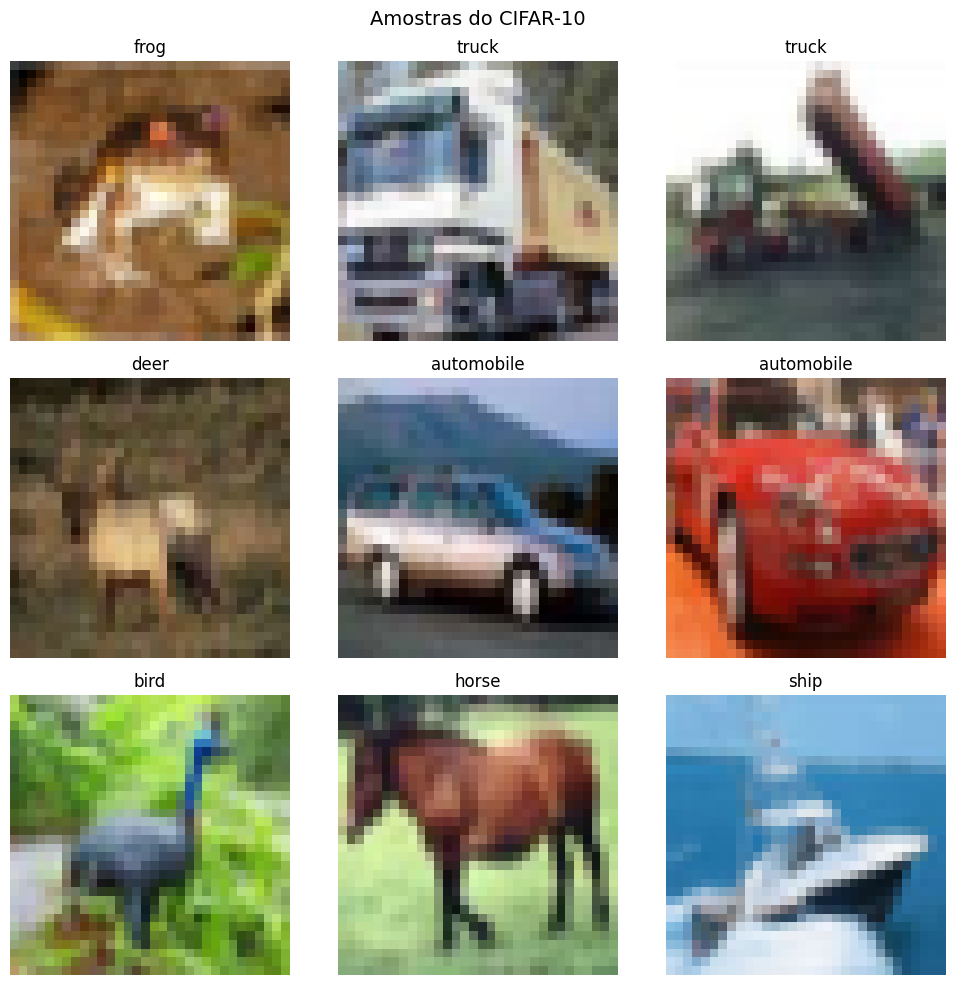

In [18]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle('Amostras do CIFAR-10', fontsize=14)
plt.tight_layout()
plt.show()

Distribuição das classes

Distribuição das classes no treino:
  airplane: 5000 imagens
  automobile: 5000 imagens
  bird: 5000 imagens
  cat: 5000 imagens
  deer: 5000 imagens
  dog: 5000 imagens
  frog: 5000 imagens
  horse: 5000 imagens
  ship: 5000 imagens
  truck: 5000 imagens


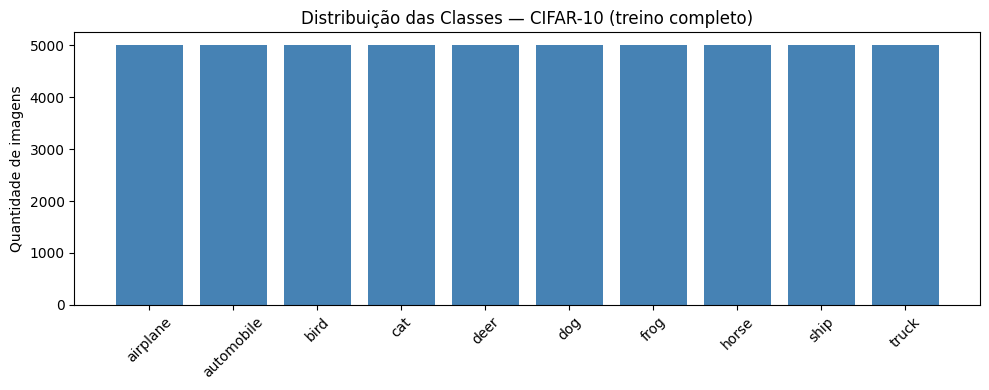

In [19]:
unique, counts = np.unique(y_train, return_counts=True)

print("Distribuição das classes no treino:")
for name, count in zip(class_names, counts):
    print(f"  {name}: {count} imagens")

plt.figure(figsize=(10, 4))
plt.bar(class_names, counts, color='steelblue')
plt.title('Distribuição das Classes — CIFAR-10 (treino completo)')
plt.ylabel('Quantidade de imagens')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Filtro cat/dog

In [20]:
import numpy as np
import matplotlib.pyplot as plt

cat_class = 3  # cat
dog_class = 5  # dog

y_train_original = y_train.reshape(-1)
y_test_original  = y_test.reshape(-1)

train_filter = np.where(
    (y_train_original == cat_class) | (y_train_original == dog_class)
)[0]
x_train_filtered = x_train[train_filter]
y_train_filtered = y_train_original[train_filter]

test_filter = np.where(
    (y_test_original == cat_class) | (y_test_original == dog_class)
)[0]
x_test_filtered = x_test[test_filter]
y_test_filtered = y_test_original[test_filter]

y_train_filtered = np.where(y_train_filtered == cat_class, 0, 1)
y_test_filtered  = np.where(y_test_filtered  == cat_class, 0, 1)

x_train_filtered = x_train_filtered.astype('float32')
x_test_filtered  = x_test_filtered.astype('float32')

print("Treino filtrado:", x_train_filtered.shape)
print("Teste filtrado:", x_test_filtered.shape)
print("Labels treino:", np.unique(y_train_filtered, return_counts=True))
print("Labels teste:", np.unique(y_test_filtered, return_counts=True))

Treino filtrado: (10000, 32, 32, 3)
Teste filtrado: (2000, 32, 32, 3)
Labels treino: (array([0, 1]), array([5000, 5000]))
Labels teste: (array([0, 1]), array([1000, 1000]))


Visualização

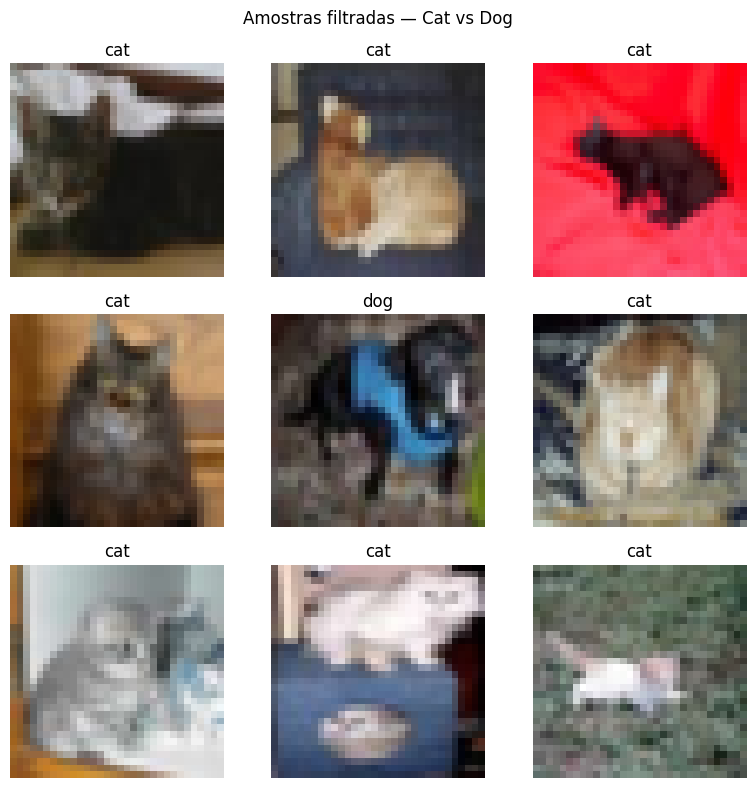

In [21]:
# Visualizar amostras do dataset filtrado
binary_names = ['cat', 'dog']

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train_filtered[i])
    label = int(y_train_filtered[i])
    plt.title(binary_names[label])
    plt.axis('off')
plt.suptitle('Amostras filtradas — Cat vs Dog')
plt.tight_layout()
plt.show()

 Few-shot (10 shots + seed variável)

In [22]:
def create_few_shot_dataset(x_data, y_data, shots_per_class=100, seed=42):
    """
    Few-shot: seleciona k amostras por classe.
    shots_per_class=100 → 100-shot learning (padrão acadêmico)
    seed variável para garantir simulações diferentes
    """
    rng = np.random.default_rng(seed)  # gerador isolado, não afeta seed global

    selected_indices = []
    for class_label in [0, 1]:
        class_indices = np.where(y_data == class_label)[0]
        chosen = rng.choice(class_indices, size=shots_per_class, replace=False)
        selected_indices.extend(chosen)

    selected_indices = np.array(selected_indices)
    return x_data[selected_indices], y_data[selected_indices]

Teste rápido da função

In [23]:
x_few_test, y_few_test = create_few_shot_dataset(
    x_train_filtered,
    y_train_filtered,
    shots_per_class=100,
    seed=42
)

print("Formato y_few:", y_few_test.shape)
print("Distribuição:", np.unique(y_few_test, return_counts=True))

Formato y_few: (200,)
Distribuição: (array([0, 1]), array([100, 100]))


Preprocessamento separado por modelo
Transfer Learning

In [24]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

IMG_SIZE = 96

def preprocess_for_mobilenet(x):
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    return x.numpy()

def preprocess_for_efficientnet(x):
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    return x.numpy()

## Modelos de Transfer Learning

Dois modelos pré-treinados no ImageNet serão utilizados como base:
- **MobileNetV2** — arquitetura leve e eficiente
- **EfficientNetB0** — arquitetura com melhor custo-benefício de acurácia

As camadas base serão congeladas (*frozen*) e apenas a cabeça de classificação será treinada no dataset few-shot.

In [25]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0

def create_mobilenet_model():
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


def create_efficientnet_model():
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

Função de simulação de few shot


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np

def run_one_simulation(seed, shots_per_class=100, epochs=20, batch_size=16):
    print(f"\n--- Simulação {seed} ---")

    # 1. Few-shot dataset
    x_few, y_few = create_few_shot_dataset(
        x_train_filtered,
        y_train_filtered,
        shots_per_class=shots_per_class,
        seed=seed
    )

    # 2. Split estratificado — garante 50% Cat e 50% Dog na validação
    x_train_few, x_val_few, y_train_few, y_val_few = train_test_split(
        x_few, y_few,
        test_size=0.2,
        random_state=seed,
        stratify=y_few
    )

    # 3. Preprocessamento separado por modelo
    x_train_mobile    = preprocess_for_mobilenet(x_train_few)
    x_val_mobile      = preprocess_for_mobilenet(x_val_few)
    x_train_efficient = preprocess_for_efficientnet(x_train_few)
    x_val_efficient   = preprocess_for_efficientnet(x_val_few)
    x_test_mobile     = preprocess_for_mobilenet(x_test_filtered)
    x_test_efficient  = preprocess_for_efficientnet(x_test_filtered)

    # 4. Criar modelos novos a cada simulação
    mobilenet_model    = create_mobilenet_model()
    efficientnet_model = create_efficientnet_model()

    # Callback EarlyStopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # 5. Treinar MobileNetV2
    history_mobile = mobilenet_model.fit(
        x_train_mobile, y_train_few,
        validation_data=(x_val_mobile, y_val_few),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # 6. Treinar EfficientNetB0
    history_efficient = efficientnet_model.fit(
        x_train_efficient, y_train_few,
        validation_data=(x_val_efficient, y_val_few),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # 7. Pesos dinâmicos baseados no val_loss da última época
    val_loss_mobile    = history_mobile.history['val_loss'][-1]
    val_loss_efficient = history_efficient.history['val_loss'][-1]

    inv_mobile    = 1 / (val_loss_mobile    + 1e-8)
    inv_efficient = 1 / (val_loss_efficient + 1e-8)
    total = inv_mobile + inv_efficient

    w_mobile    = inv_mobile    / total
    w_efficient = inv_efficient / total

    print(f"  val_loss → MobileNet={val_loss_mobile:.4f} | EfficientNet={val_loss_efficient:.4f}")
    print(f"  Pesos   → MobileNet={w_mobile:.3f} | EfficientNet={w_efficient:.3f}")

    # 8. Previsões com preprocessamento correto por modelo
    pred_mobile    = mobilenet_model.predict(x_test_mobile,    verbose=0)
    pred_efficient = efficientnet_model.predict(x_test_efficient, verbose=0)

    # 9. Cenário 1 — Ensemble simples (média aritmética)
    pred_simple   = (pred_mobile + pred_efficient) / 2

    # 10. Cenário 2 — Ensemble ponderado (pesos dinâmicos)
    pred_weighted = (w_mobile * pred_mobile) + (w_efficient * pred_efficient)

    # 11. Converter probabilidades em classes
    y_pred_simple   = (pred_simple   >= 0.5).astype(int).reshape(-1)
    y_pred_weighted = (pred_weighted >= 0.5).astype(int).reshape(-1)

    # 12. Métricas Cenário 1
    simple_metrics = {
        "accuracy":  accuracy_score( y_test_filtered, y_pred_simple),
        "precision": precision_score(y_test_filtered, y_pred_simple,   zero_division=0),
        "recall":    recall_score(   y_test_filtered, y_pred_simple,   zero_division=0),
        "f1":        f1_score(       y_test_filtered, y_pred_simple,   zero_division=0)
    }

    # 13. Métricas Cenário 2
    weighted_metrics = {
        "accuracy":  accuracy_score( y_test_filtered, y_pred_weighted),
        "precision": precision_score(y_test_filtered, y_pred_weighted, zero_division=0),
        "recall":    recall_score(   y_test_filtered, y_pred_weighted, zero_division=0),
        "f1":        f1_score(       y_test_filtered, y_pred_weighted, zero_division=0)
    }

    # 14. Salvar pesos usados para análise posterior
    simple_metrics["w_mobile"]    = w_mobile
    simple_metrics["w_efficient"] = w_efficient

    # 15. Limpar memória GPU/RAM
    del mobilenet_model, efficientnet_model
    tf.keras.backend.clear_session()

    return simple_metrics, weighted_metrics

Teste de 1 simulação antes do loop

In [27]:
simple_result, weighted_result = run_one_simulation(
    seed=1,
    shots_per_class=100,
    epochs=20,
    batch_size=16
)

print("\nCenário 1 - Ensemble Simples:")
print(simple_result)
print("\nCenário 2 - Ensemble Ponderado:")
print(weighted_result)


--- Simulação 1 ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  val_loss → MobileNet=0.4038 | EfficientNet=0.6931
  Pesos   → MobileNet=0.632 | EfficientNet=0.368

Cenário 1 - Ensemble Simples:
{'accuracy': 0.7335, 'precision': 0.732801595214357, 'recall': 0.735, 'f1': 0.7338991512730904, 'w_mobile': 0.63187655625383, 'w_efficient': 0.36812344374617}

Cenário 2 - Ensemble Ponderado:
{'accuracy': 0.731, 'precision': 0.7282608695652174, 'recall': 0.737, 'f1': 0.7326043737574552}


Loop das 30 simulações

In [26]:
import pandas as pd

results = []
NUM_SIMULATIONS = 30

for sim in range(1, NUM_SIMULATIONS + 1):
    simple_metrics, weighted_metrics = run_one_simulation(
        seed=sim,
        shots_per_class=100,  # ← 100-shot em todas as simulações
        epochs=20,
        batch_size=16
    )

    results.append({
        "simulation": sim,

        # Cenário 1
        "simple_accuracy":  simple_metrics["accuracy"],
        "simple_precision": simple_metrics["precision"],
        "simple_recall":    simple_metrics["recall"],
        "simple_f1":        simple_metrics["f1"],

        # Cenário 2
        "weighted_accuracy":  weighted_metrics["accuracy"],
        "weighted_precision": weighted_metrics["precision"],
        "weighted_recall":    weighted_metrics["recall"],
        "weighted_f1":        weighted_metrics["f1"],

        # Pesos usados (para análise e relatório)
        "w_mobile":    simple_metrics["w_mobile"],
        "w_efficient": simple_metrics["w_efficient"]
    })

results_df = pd.DataFrame(results)
results_df


--- Simulação 1 ---
  val_loss → MobileNet=0.4548 | EfficientNet=0.6934
  Pesos   → MobileNet=0.604 | EfficientNet=0.396

--- Simulação 2 ---
  val_loss → MobileNet=0.6342 | EfficientNet=0.6931
  Pesos   → MobileNet=0.522 | EfficientNet=0.478

--- Simulação 3 ---
  val_loss → MobileNet=0.5024 | EfficientNet=0.6933
  Pesos   → MobileNet=0.580 | EfficientNet=0.420

--- Simulação 4 ---
  val_loss → MobileNet=0.6188 | EfficientNet=0.6937
  Pesos   → MobileNet=0.529 | EfficientNet=0.471

--- Simulação 5 ---
  val_loss → MobileNet=0.5691 | EfficientNet=0.6934
  Pesos   → MobileNet=0.549 | EfficientNet=0.451

--- Simulação 6 ---
  val_loss → MobileNet=0.3859 | EfficientNet=0.6931
  Pesos   → MobileNet=0.642 | EfficientNet=0.358

--- Simulação 7 ---
  val_loss → MobileNet=0.5592 | EfficientNet=0.6934
  Pesos   → MobileNet=0.554 | EfficientNet=0.446

--- Simulação 8 ---
  val_loss → MobileNet=0.4726 | EfficientNet=0.6928
  Pesos   → MobileNet=0.594 | EfficientNet=0.406

--- Simulação 9 ---
  v

,simulation,simple_accuracy,simple_precision,simple_recall,simple_f1,weighted_accuracy,weighted_precision,weighted_recall,weighted_f1,w_mobile,w_efficient
0,1,0.7285,0.759954,0.668,0.711016,0.7295,0.758737,0.673,0.713302,0.603890,0.396110
1,2,0.7080,0.728070,0.664,0.694561,0.7090,0.728665,0.666,0.695925,0.522216,0.477784
2,3,0.7225,0.751982,0.664,0.705258,0.7250,0.750557,0.674,0.710221,0.579798,0.420202
3,4,0.7135,0.697138,0.755,0.724916,0.7135,0.697138,0.755,0.724916,0.528519,0.471481
4,5,0.7300,0.711786,0.773,0.741131,0.7300,0.712177,0.772,0.740883,0.549193,0.450807
5,6,0.7420,0.757447,0.712,0.734021,0.7395,0.751840,0.715,0.732957,0.642335,0.357665
6,7,0.7280,0.800792,0.607,0.690557,0.7290,0.803714,0.606,0.690992,0.553540,0.446460
7,8,0.7280,0.750549,0.683,0.715183,0.7275,0.750827,0.681,0.714211,0.594479,0.405521
8,9,0.7425,0.764449,0.701,0.731351,0.7470,0.766739,0.710,0.737279,0.582387,0.417613
9,10,0.7215,0.750849,0.663,0.704195,0.7235,0.749164,0.672,0.708487,0.590565,0.409435


## Verificação de Independência entre Simulações

In [28]:
from itertools import combinations
import numpy as np

# Verificar sobreposição entre subconjuntos de treino das simulações
all_indices = {}
for sim in range(1, 31):
    rng = np.random.default_rng(sim)
    indices = []
    for class_label in [0, 1]:
        class_indices = np.where(y_train_filtered == class_label)[0]
        chosen = rng.choice(class_indices, size=100, replace=False)
        indices.extend(chosen.tolist())
    all_indices[sim] = set(indices)

# Sobreposição entre pares de simulações
overlaps = []
for s1, s2 in combinations(range(1, 31), 2):
    overlap = len(all_indices[s1] & all_indices[s2])
    overlaps.append(overlap)

print(f"Sobreposição média entre simulações: {np.mean(overlaps):.1f} imagens")
print(f"Sobreposição máxima: {np.max(overlaps)} imagens")
print(f"Sobreposição mínima: {np.min(overlaps)} imagens")

# Verificar vazamento treino→teste usando os pixels das imagens
# Converte imagens para tuplas para comparação
print("\nVerificando vazamento treino→teste...")
train_hashes = set(map(lambda x: hash(x.tobytes()), x_train_filtered))
test_hashes  = set(map(lambda x: hash(x.tobytes()), x_test_filtered))
vazamento = len(train_hashes & test_hashes)
print(f"Vazamento treino→teste: {vazamento} imagens")
print("(esperado: 0 — CIFAR-10 garante separacao por design)")

Sobreposição média entre simulações: 4.0 imagens
Sobreposição máxima: 11 imagens
Sobreposição mínima: 0 imagens

Verificando vazamento treino→teste...
Vazamento treino→teste: 0 imagens
(esperado: 0 — CIFAR-10 garante separacao por design)


Verificação de Domínio: Impacto da Similaridade Visual

In [29]:
## Teste 2 — Verificação de Domínio: Impacto da Similaridade Visual
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# Pares de classes para testar
pares_teste = [
    (0, 6, 'airplane vs frog'),    # muito distintos — já sabemos que funciona
    (8, 4, 'ship vs deer'),        # muito distintos
    (1, 7, 'automobile vs horse'), # moderadamente distintos
    (3, 5, 'cat vs dog'),          # nosso caso original — alta similaridade
]

def run_domain_test(class_a, class_b, nome, n_sims=10, shots=100, epochs=20, batch=16):
    print(f"\n=== {nome} ===")

    # Filtrar classes
    y_tr = y_train.reshape(-1)
    y_te = y_test.reshape(-1)

    tr_filter = np.where((y_tr == class_a) | (y_tr == class_b))[0]
    te_filter = np.where((y_te == class_a) | (y_te == class_b))[0]

    x_tr = x_train[tr_filter].astype('float32')
    y_tr = np.where(y_tr[tr_filter] == class_a, 0, 1)
    x_te = x_test[te_filter].astype('float32')
    y_te = np.where(y_te[te_filter] == class_a, 0, 1)

    accs_simples    = []
    accs_ponderados = []

    for sim in range(1, n_sims + 1):
        # Few-shot
        rng = np.random.default_rng(sim)
        indices = []
        for cl in [0, 1]:
            ci = np.where(y_tr == cl)[0]
            indices.extend(rng.choice(ci, size=shots, replace=False).tolist())
        x_few = x_tr[indices]
        y_few = y_tr[indices]

        # Split estratificado
        from sklearn.model_selection import train_test_split
        x_trn, x_val, y_trn, y_val = train_test_split(
            x_few, y_few, test_size=0.2, random_state=sim, stratify=y_few
        )

        # Preprocess
        x_trn_m = preprocess_for_mobilenet(x_trn)
        x_val_m = preprocess_for_mobilenet(x_val)
        x_trn_e = preprocess_for_efficientnet(x_trn)
        x_val_e = preprocess_for_efficientnet(x_val)
        x_te_m  = preprocess_for_mobilenet(x_te)
        x_te_e  = preprocess_for_efficientnet(x_te)

        # Modelos
        mob = create_mobilenet_model()
        eff = create_efficientnet_model()

        from tensorflow.keras.callbacks import EarlyStopping
        es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        mob.fit(x_trn_m, y_trn, validation_data=(x_val_m, y_val),
                epochs=epochs, batch_size=batch, callbacks=[es], verbose=0)
        eff.fit(x_trn_e, y_trn, validation_data=(x_val_e, y_val),
                epochs=epochs, batch_size=batch, callbacks=[es], verbose=0)

        # Pesos
        vl_m = mob.history.history['val_loss'][-1]
        vl_e = eff.history.history['val_loss'][-1]
        inv_m = 1 / (vl_m + 1e-8)
        inv_e = 1 / (vl_e + 1e-8)
        total = inv_m + inv_e
        w_m = inv_m / total
        w_e = inv_e / total

        # Previsões
        pm = mob.predict(x_te_m, verbose=0)
        pe = eff.predict(x_te_e, verbose=0)

        y_simple   = ((pm + pe) / 2 >= 0.5).astype(int).reshape(-1)
        y_weighted = ((w_m * pm + w_e * pe) >= 0.5).astype(int).reshape(-1)

        accs_simples.append(accuracy_score(y_te, y_simple))
        accs_ponderados.append(accuracy_score(y_te, y_weighted))

        import tensorflow as tf
        del mob, eff
        tf.keras.backend.clear_session()

    print(f"  Simples:    {np.mean(accs_simples):.4f} ± {np.std(accs_simples):.4f}")
    print(f"  Ponderado:  {np.mean(accs_ponderados):.4f} ± {np.std(accs_ponderados):.4f}")
    print(f"  Diferença:  {np.mean(accs_ponderados) - np.mean(accs_simples):+.4f}")

    return {
        'par': nome,
        'simples':   round(np.mean(accs_simples), 4),
        'ponderado': round(np.mean(accs_ponderados), 4),
        'diferenca': round(np.mean(accs_ponderados) - np.mean(accs_simples), 4)
    }

# Rodar os 4 pares
resultados_dominio = []
for class_a, class_b, nome in pares_teste:
    r = run_domain_test(class_a, class_b, nome, n_sims=10)
    resultados_dominio.append(r)

# Tabela final
df_dominio = pd.DataFrame(resultados_dominio)
df_dominio.columns = ['Par de Classes', 'Ensemble Simples', 'Ensemble Ponderado', 'Diferença']
print("\n=== RESULTADO FINAL ===")
print(df_dominio.to_string(index=False))


=== airplane vs frog ===
  Simples:    0.9597 ± 0.0035
  Ponderado:  0.9602 ± 0.0035
  Diferença:  +0.0005

=== ship vs deer ===
  Simples:    0.9678 ± 0.0034
  Ponderado:  0.9678 ± 0.0035
  Diferença:  -0.0000

=== automobile vs horse ===
  Simples:    0.9779 ± 0.0029
  Ponderado:  0.9776 ± 0.0031
  Diferença:  -0.0003

=== cat vs dog ===
  Simples:    0.7247 ± 0.0108
  Ponderado:  0.7248 ± 0.0116
  Diferença:  +0.0001

=== RESULTADO FINAL ===
     Par de Classes  Ensemble Simples  Ensemble Ponderado  Diferença
   airplane vs frog            0.9598              0.9602     0.0005
       ship vs deer            0.9678              0.9678    -0.0000
automobile vs horse            0.9779              0.9776    -0.0003
         cat vs dog            0.7247              0.7248     0.0001


Estatísticas descritivas das 30 **simulações**

In [36]:
results_df.describe()
results_df.to_csv("results_30_simulations.csv", index=False)

Resumo comparativo dos cenários

In [28]:
print("=" * 45)
print("ENSEMBLE SIMPLES")
print(f"  Acurácia média:   {results_df['simple_accuracy'].mean():.4f}")
print(f"  Desvio padrão:    {results_df['simple_accuracy'].std():.4f}")

print("\nENSEMBLE PONDERADO")
print(f"  Acurácia média:   {results_df['weighted_accuracy'].mean():.4f}")
print(f"  Desvio padrão:    {results_df['weighted_accuracy'].std():.4f}")

print("\nPESOS MÉDIOS USADOS")
print(f"  MobileNet:        {results_df['w_mobile'].mean():.3f}")
print(f"  EfficientNet:     {results_df['w_efficient'].mean():.3f}")
print("=" * 45)

ENSEMBLE SIMPLES
  Acurácia média:   0.7231
  Desvio padrão:    0.0157

ENSEMBLE PONDERADO
  Acurácia média:   0.7237
  Desvio padrão:    0.0154

PESOS MÉDIOS USADOS
  MobileNet:        0.572
  EfficientNet:     0.428


Teste t pareado (hipótese)

In [29]:
from scipy.stats import ttest_rel, t
import numpy as np

t_stat, p_value = ttest_rel(
    results_df["weighted_accuracy"],
    results_df["simple_accuracy"]
)

diff = results_df["weighted_accuracy"] - results_df["simple_accuracy"]
n = len(diff)
ci = t.interval(0.95, df=n-1, loc=diff.mean(), scale=diff.std()/np.sqrt(n))

print(f"  IC 95%: [{ci[0]:.4f}, {ci[1]:.4f}]")

alpha = 0.05

print("=" * 45)
print("TESTE T PAREADO — H₀ vs H₁")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value:     {p_value:.4f}")
print(f"  Alpha:       {alpha}")
print()
if p_value < alpha:
    print(" Rejeita H₀ — diferença significativa.")
    print(" O ensemble ponderado é significativamente melhor.")
else:
    print("  Falha em rejeitar H₀ — sem diferença significativa.")
print("=" * 45)

  IC 95%: [-0.0000, 0.0013]
TESTE T PAREADO — H₀ vs H₁
  T-statistic: 1.9190
  P-value:     0.0649
  Alpha:       0.05

  Falha em rejeitar H₀ — sem diferença significativa.


Boxplot — Comparação de Acurácia

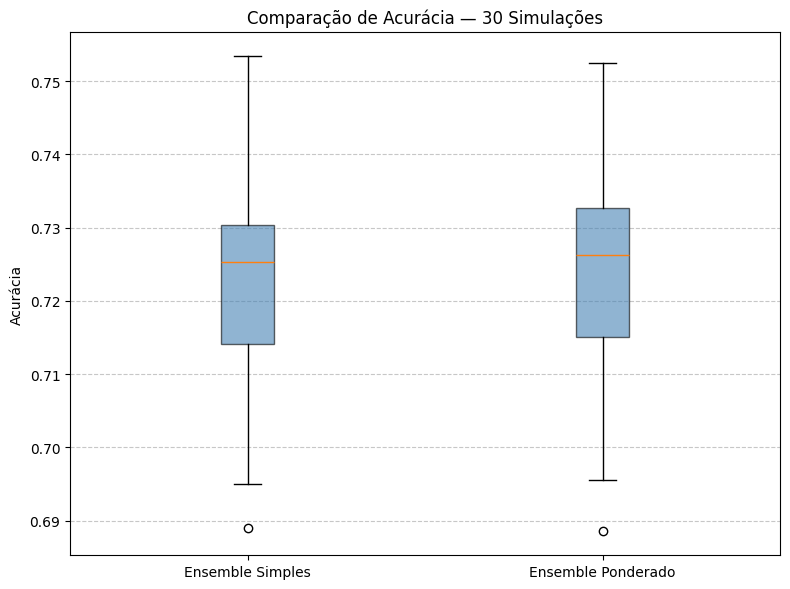

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.boxplot(
    [results_df["simple_accuracy"], results_df["weighted_accuracy"]],
    tick_labels=["Ensemble Simples", "Ensemble Ponderado"],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
plt.ylabel("Acurácia")
plt.title("Comparação de Acurácia — 30 Simulações")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Acurácia por Simulação

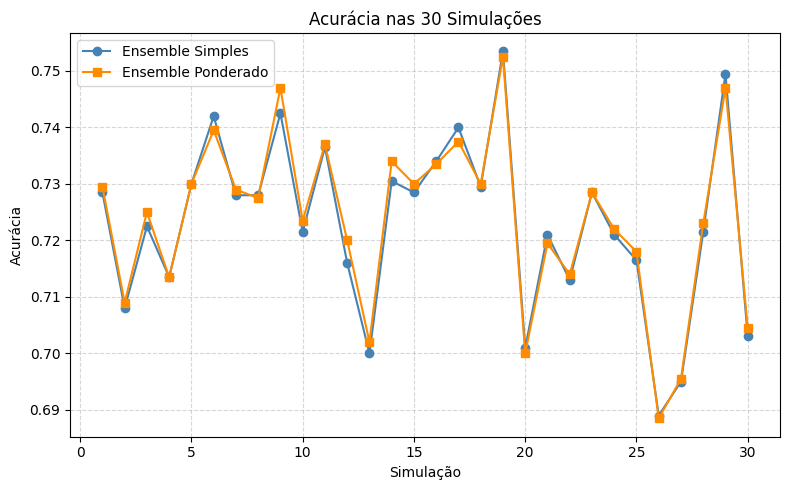

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["simulation"], results_df["simple_accuracy"],
         marker='o', label='Ensemble Simples', color='steelblue')
plt.plot(results_df["simulation"], results_df["weighted_accuracy"],
         marker='s', label='Ensemble Ponderado', color='darkorange')
plt.xlabel("Simulação")
plt.ylabel("Acurácia")
plt.title("Acurácia nas 30 Simulações")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Média das Métricas por Cenário

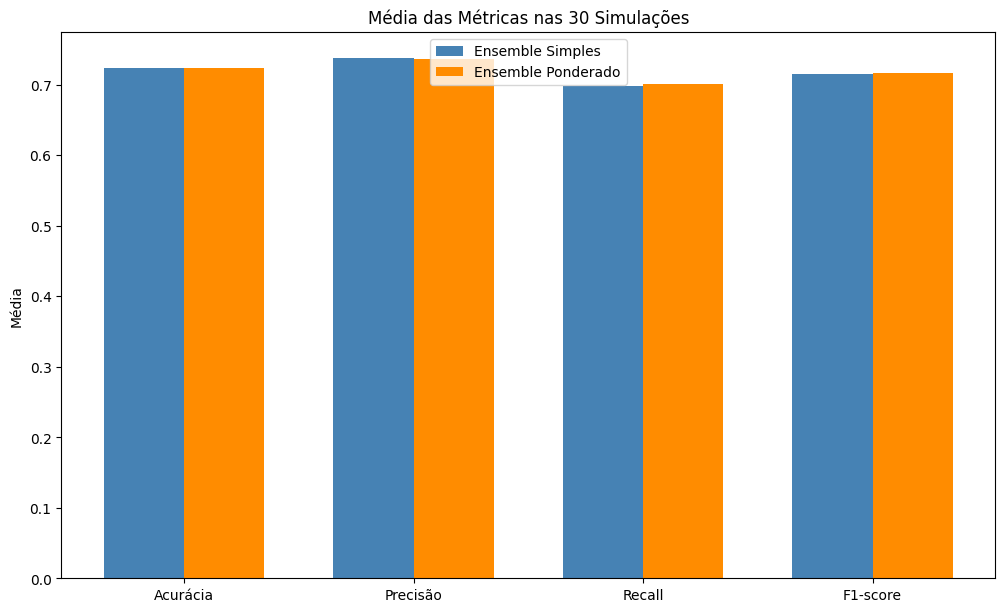

In [32]:
metrics = ["accuracy", "precision", "recall", "f1"]

simple_means = [
    results_df["simple_accuracy"].mean(),
    results_df["simple_precision"].mean(),
    results_df["simple_recall"].mean(),
    results_df["simple_f1"].mean()
]

weighted_means = [
    results_df["weighted_accuracy"].mean(),
    results_df["weighted_precision"].mean(),
    results_df["weighted_recall"].mean(),
    results_df["weighted_f1"].mean()
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, simple_means, width, label="Ensemble Simples", color='steelblue')
plt.bar(x + width/2, weighted_means, width, label="Ensemble Ponderado", color='darkorange')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.xticks(x, ["Acurácia", "Precisão", "Recall", "F1-score"])
plt.ylabel("Média")
plt.title("Média das Métricas nas 30 Simulações")
plt.legend()
plt.grid(axis="y")

plt.show()

Distribuição da Diferença de Acurácia

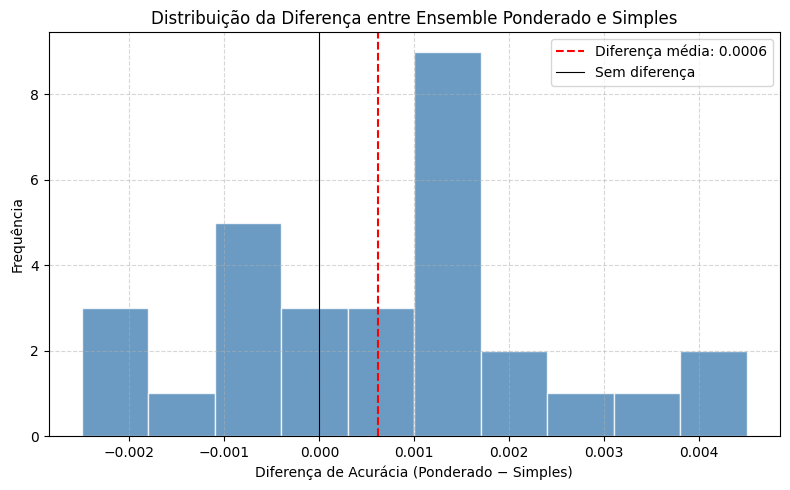

In [33]:
results_df["accuracy_difference"] = (
    results_df["weighted_accuracy"] - results_df["simple_accuracy"]
)

plt.figure(figsize=(8, 5))
plt.hist(results_df["accuracy_difference"], bins=10,
         color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(results_df["accuracy_difference"].mean(),
            color='red', linestyle='--', label=f'Diferença média: {results_df["accuracy_difference"].mean():.4f}')
plt.axvline(0, color='black', linestyle='-', linewidth=0.8, label='Sem diferença')  # ← novo
plt.xlabel("Diferença de Acurácia (Ponderado − Simples)")
plt.ylabel("Frequência")
plt.title("Distribuição da Diferença entre Ensemble Ponderado e Simples")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Tabela Resumo Final

In [34]:
summary_table = pd.DataFrame({
    "Métrica":            ["Acurácia", "Precisão", "Recall", "F1-score"],
    "Ensemble Simples":   [round(v, 4) for v in simple_means],
    "Ensemble Ponderado": [round(v, 4) for v in weighted_means],
    "Diferença":          [round(w - s, 4) for s, w in zip(simple_means, weighted_means)]
})

summary_table

,Métrica,Ensemble Simples,Ensemble Ponderado,Diferença
0,Acurácia,0.7231,0.7237,0.0006
1,Precisão,0.7376,0.7368,-0.0008
2,Recall,0.6983,0.7014,0.0031
3,F1-score,0.7156,0.7170,0.0014


Matriz de Confusão — Melhor Simulação

Melhor simulação: 19 | Acurácia: 0.7525


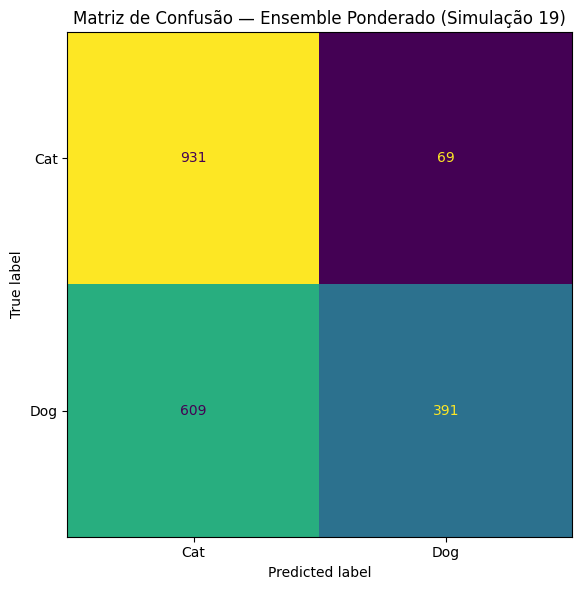

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Pega a simulação com maior acurácia ponderada
best_sim = results_df["weighted_accuracy"].idxmax()
best_seed = results_df.loc[best_sim, "simulation"]

print(f"Melhor simulação: {best_seed} | Acurácia: {results_df.loc[best_sim, 'weighted_accuracy']:.4f}")

# Roda novamente só para pegar as predições
x_few_b, y_few_b = create_few_shot_dataset(
    x_train_filtered, y_train_filtered,
    shots_per_class=100, seed=best_seed
)

x_few_mobile_b    = preprocess_for_mobilenet(x_few_b)
x_few_efficient_b = preprocess_for_efficientnet(x_few_b)
x_test_mobile_b    = preprocess_for_mobilenet(x_test_filtered)
x_test_efficient_b = preprocess_for_efficientnet(x_test_filtered)

mob_b = create_mobilenet_model()
eff_b = create_efficientnet_model()

h_mob = mob_b.fit(x_few_mobile_b,    y_few_b, epochs=10, batch_size=16, validation_split=0.2, verbose=0)
h_eff = eff_b.fit(x_few_efficient_b, y_few_b, epochs=10, batch_size=16, validation_split=0.2, verbose=0)

val_loss_m = h_mob.history['val_loss'][-1]
val_loss_e = h_eff.history['val_loss'][-1]
inv_m = 1 / (val_loss_m + 1e-8)
inv_e = 1 / (val_loss_e + 1e-8)
total = inv_m + inv_e
w_m = inv_m / total
w_e = inv_e / total

pred_m = mob_b.predict(x_test_mobile_b,    verbose=0)
pred_e = eff_b.predict(x_test_efficient_b, verbose=0)
pred_w = (w_m * pred_m) + (w_e * pred_e)
y_pred_best = (pred_w >= 0.5).astype(int).reshape(-1)

cm = confusion_matrix(y_test_filtered, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title(f"Matriz de Confusão — Ensemble Ponderado (Simulação {best_seed})")
plt.tight_layout()
plt.show()

del mob_b, eff_b
tf.keras.backend.clear_session()

In [38]:
# Shapiro-Wilk
from scipy.stats import shapiro
stat, p_shapiro = shapiro(results_df["weighted_accuracy"] - results_df["simple_accuracy"])
print(f"Shapiro-Wilk: W={stat:.4f}, p={p_shapiro:.4f}")

# Wilcoxon
from scipy.stats import wilcoxon
stat_w, p_wilcoxon = wilcoxon(results_df["weighted_accuracy"], results_df["simple_accuracy"])
print(f"Wilcoxon: W={stat_w:.4f}, p={p_wilcoxon:.4f}")

# Cohen's d
diff = results_df["weighted_accuracy"] - results_df["simple_accuracy"]
cohens_d = diff.mean() / diff.std()
print(f"Cohen's d: {cohens_d:.4f}")


Shapiro-Wilk: W=0.9683, p=0.4943
Wilcoxon: W=112.5000, p=0.0652
Cohen's d: 0.3504
